# 02 — Feature Engineering
Création des variables à partir des données nettoyées.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skrub import TableReport

In [2]:
df = pd.read_parquet('../data/decp_clean.parquet')
print(df.shape)
df.head()

(8756, 10)


,id,objet,acheteur_id,montant,dureeMois,offresRecues,procedure,codeCPV,nb_titulaires,dateNotification
0,2022-884095-01,Transports collectifs pour la Ville d'Orvault:...,21440114300018,46000.0,12.0,1,Procédure adaptée,60,1,2022-07-29
1,2024-0202403100,"Travaux d'éclairage public, de signalisation l...",21680066400015,253530.0,8.0,2,Procédure adaptée,45,1,2024-07-11
2,24-131-00,"LE MOLAY LITTRY - 53, 55, 57, 59, 61 et 63 rou...",78070570300012,113278.0,2.0,1,Procédure adaptée,45,1,2024-08-29
3,22-076,"Réalisation 11 logements collectifs, lot B5-D3...",45220075100025,46678.0,24.0,1,Procédure avec négociation,44,1,2022-11-23
4,22-207,Construction de 2 bâtiments totalisant 44 loge...,45220075100025,59354.0,22.0,1,Procédure adaptée,44,1,2022-12-07


## Exploration avec skrub

In [3]:
TableReport(df)

Processing column   6 / 10

,,,,,,,,,,


## Features métier

In [4]:
df['montant_log'] = np.log1p(df['montant'])

In [5]:
df['offre_unique'] = (df['offresRecues'] == 1).astype(int)
print(f'Marchés avec 1 seule offre : {df["offre_unique"].sum()}')

Marchés avec 1 seule offre : 2137


In [6]:
df['sans_concurrence'] = df['procedure'].str.contains(
    'sans publicité|sans mise en concurrence', case=False, na=False
).astype(int)
print(f'Marchés sans concurrence : {df["sans_concurrence"].sum()}')

Marchés sans concurrence : 233


In [7]:
df['seuil_shaving'] = ((df['montant'] >= 35_000) & (df['montant'] < 40_000)).astype(int)
print(f'Marchés avec seuil shaving : {df["seuil_shaving"].sum()}')

Marchés avec seuil shaving : 265


In [8]:
df['duree_longue'] = (df['dureeMois'] > 48).astype(int)
print(f'Marchés avec durée > 48 mois : {df["duree_longue"].sum()}')

Marchés avec durée > 48 mois : 280


In [9]:
df['mois_notification'] = df['dateNotification'].dt.month.fillna(0).astype(int)

In [10]:
procedure_map = {
    'Procédure adaptée': 0,
    "Appel d'offres ouvert": 1,
    'Marché passé sans publicité ni mise en concurrence préalable': 2,
    'Procédure avec négociation': 3,
    "Appel d'offres restreint": 4,
    'Procédure négociée ouverte': 5,
    'Dialogue compétitif': 6,
}
df['procedure_code'] = df['procedure'].map(procedure_map).fillna(-1).astype(int)

## Features mathématiques

In [11]:
df['montant_par_mois'] = df['montant'] / (df['dureeMois'] + 1)

In [12]:
df['z_montant_cpv'] = df.groupby('codeCPV')['montant'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1)
)

## Features d'agrégation

In [13]:
df['taux_sans_conc_acheteur'] = df.groupby('acheteur_id')['sans_concurrence'].transform('mean')

In [14]:
df['nb_marches_acheteur'] = df.groupby('acheteur_id')['id'].transform('count')

In [15]:
df['montant_moyen_acheteur'] = df.groupby('acheteur_id')['montant'].transform('mean')
df['ratio_montant_acheteur'] = df['montant'] / (df['montant_moyen_acheteur'] + 1)

## PCA

In [16]:
features_pca = ['montant_log', 'dureeMois', 'offresRecues', 'montant_par_mois', 'z_montant_cpv']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_pca].fillna(0))

pca = PCA(n_components=2)
composantes = pca.fit_transform(X_scaled)

df['pca_1'] = composantes[:, 0]
df['pca_2'] = composantes[:, 1]

print(f'Variance expliquée : {pca.explained_variance_ratio_.sum():.1%}')

Variance expliquée : 50.1%


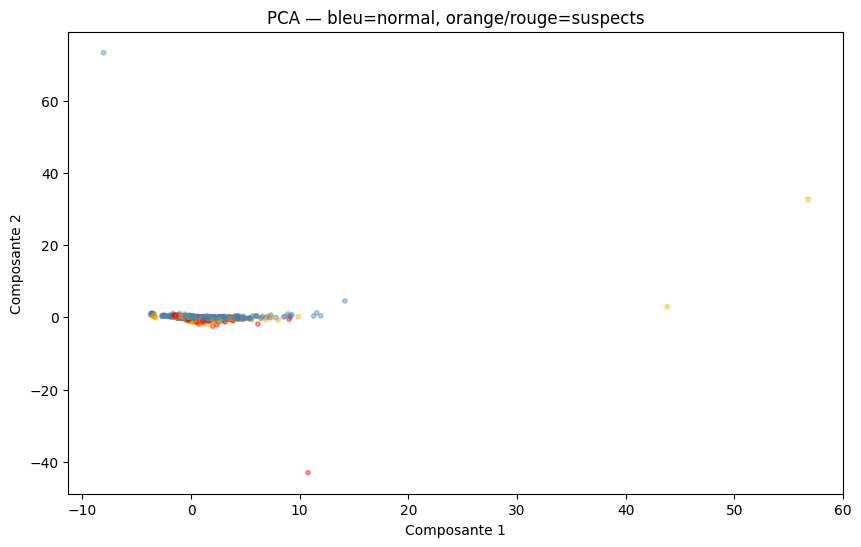

In [17]:
nb_signaux = df['offre_unique'] + df['sans_concurrence'] + df['seuil_shaving'] + df['duree_longue']
couleurs = nb_signaux.map({0: 'steelblue', 1: 'orange', 2: 'red', 3: 'darkred', 4: 'black'})

plt.figure(figsize=(10, 6))
plt.scatter(df['pca_1'], df['pca_2'], c=couleurs, alpha=0.4, s=10)
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.title('PCA — bleu=normal, orange/rouge=suspects')
plt.savefig('../plots/pca.png', dpi=150)
plt.show()

## Label et sauvegarde

In [18]:
df['label'] = (nb_signaux >= 1).astype(int)
print(f'Suspects : {df["label"].sum()} / {len(df)}')

Suspects : 2575 / 8756


In [19]:
df.to_parquet('../data/decp_features.parquet', index=False)
print('Sauvegardé : data/decp_features.parquet')

Sauvegardé : data/decp_features.parquet
